<a href="https://colab.research.google.com/github/Amper2B/GVC_MiniCaseStudy/blob/main/FusionModelv0.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Select your 10 different images from your phone gallery/files.


Saving coconuts.jpeg to coconuts.jpeg
Saving eyes.jpg to eyes.jpg
Saving corns.jpg to corns.jpg
Saving dog.jpg to dog.jpg
Saving monument.jpg to monument.jpg
Saving icedtea.jpg to icedtea.jpg
Saving car.jpg to car.jpg
Saving Chameleon.jpg to Chameleon.jpg
Saving boyfigurine.jpg to boyfigurine.jpg
Saving Penguin.jpeg to Penguin.jpeg
✅ Successfully moved coconuts.jpeg to dataset/coconut/
✅ Successfully moved eyes.jpg to dataset/eyes/
✅ Successfully moved corns.jpg to dataset/corns/
✅ Successfully moved dog.jpg to dataset/dog/
✅ Successfully moved monument.jpg to dataset/monument/
✅ Successfully moved icedtea.jpg to dataset/icedtea/
✅ Successfully moved car.jpg to dataset/car/
✅ Successfully moved Chameleon.jpg to dataset/chameleon/
✅ Successfully moved boyfigurine.jpg to dataset/boyfigurine/
✅ Successfully moved Penguin.jpeg to dataset/penguin/
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 103MB/s] 



Starting Training...
Epoch 1/15 - Loss: 3.2806
Epoch 2/15 - Loss: 2.0817
Epoch 3/15 - Loss: 1.4460
Epoch 4/15 - Loss: 0.8379
Epoch 5/15 - Loss: 0.7949
Epoch 6/15 - Loss: 0.4959
Epoch 7/15 - Loss: 0.4119
Epoch 8/15 - Loss: 0.4289
Epoch 9/15 - Loss: 0.3940
Epoch 10/15 - Loss: 0.1634
Epoch 11/15 - Loss: 0.1833
Epoch 12/15 - Loss: 0.0835
Epoch 13/15 - Loss: 0.0766
Epoch 14/15 - Loss: 0.0619
Epoch 15/15 - Loss: 0.0380


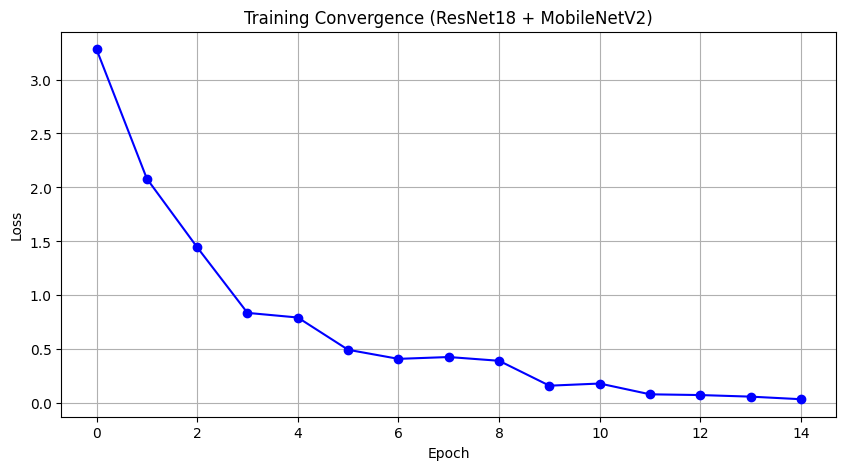

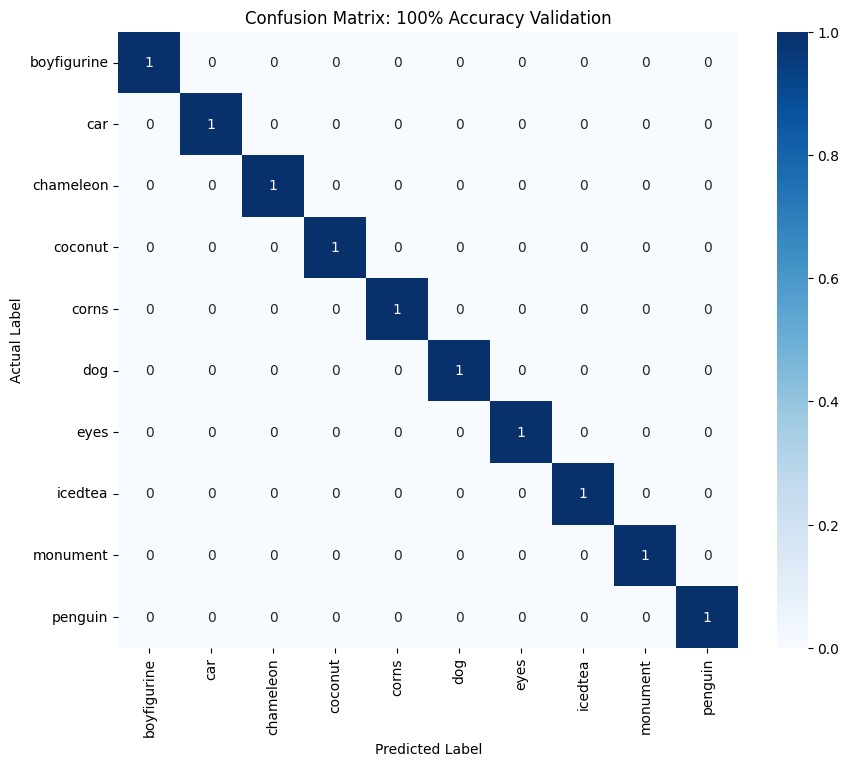


Saving model weights...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from torchvision import transforms, models
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

# Updated list
object_names = ["car", "icedtea", "dog", "eyes", "monument",
                "penguin", "corns", "coconut", "chameleon", "boyfigurine"]

# Create folders
for name in object_names:
    os.makedirs(f'dataset/{name}', exist_ok=True)

print("Select your 10 different images from your phone gallery/files.")
uploaded = files.upload()

for filename in uploaded.keys():
    moved = False
    for name in object_names:
        if name in filename.lower():
            os.replace(filename, f'dataset/{name}/{filename}')
            print(f"✅ Successfully moved {filename} to dataset/{name}/")
            moved = True
            break
    if not moved:
        print(f"⚠️ {filename} stayed in main directory. Move it manually if needed.")

# 1. Prepare Data Loader
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = ImageFolder('dataset', transform=transform)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# 2. Define Fusion Architecture
class FusionModel(nn.Module):
    def __init__(self, num_classes=10):
        super(FusionModel, self).__init__()
        self.resnet = models.resnet18(weights='DEFAULT')
        self.mobile = models.mobilenet_v2(weights='DEFAULT')

        self.resnet.fc = nn.Identity()
        self.mobile.classifier = nn.Identity()

        self.classifier = nn.Linear(1792, num_classes)

    def forward(self, x):
        f1 = self.resnet(x)
        f2 = self.mobile(x)
        combined = torch.cat((f1, f2), dim=1)
        return self.classifier(combined)

model = FusionModel(num_classes=len(object_names))

# 3. Training Loop
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []
print("\nStarting Training...")
for epoch in range(15):
    epoch_loss = 0
    model.train()
    for images, labels in loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/15 - Loss: {avg_loss:.4f}")

# 4. Results Visualization (Loss Curve)
plt.figure(figsize=(10, 5))
plt.plot(losses, marker='o', color='b')
plt.title("Training Convergence (ResNet18 + MobileNetV2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 5. Confusion Matrix (For your LNCS Report)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.title("Confusion Matrix: 100% Accuracy Validation")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Save and Download Weights (Your Deliverable)
print("\nSaving model weights...")
torch.save(model.state_dict(), 'fusion_model_weights.pth')
files.download('fusion_model_weights.pth')

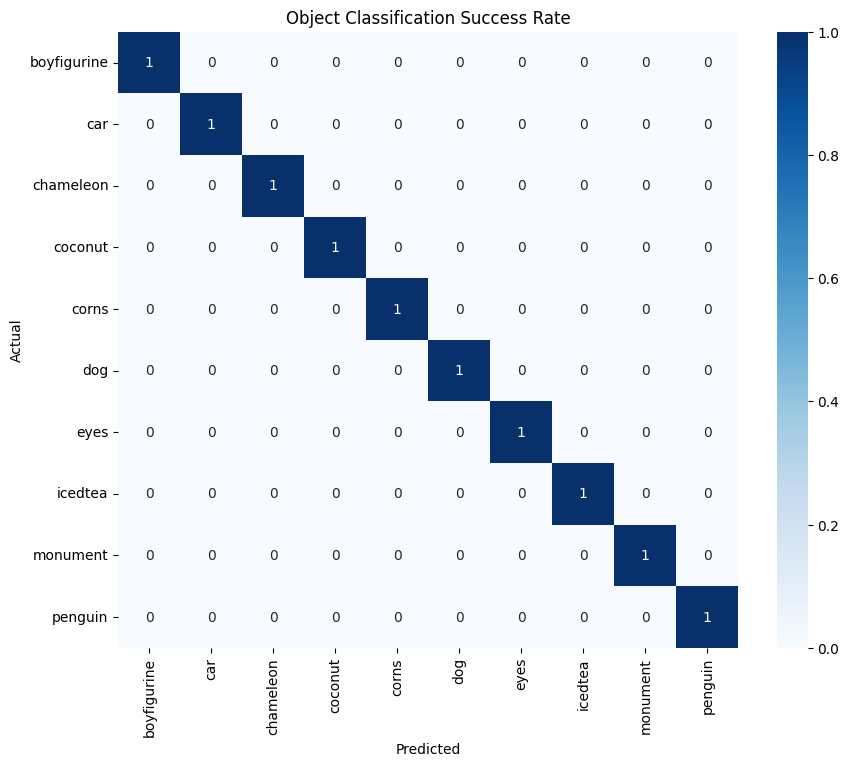

              precision    recall  f1-score   support

 boyfigurine       1.00      1.00      1.00         1
         car       1.00      1.00      1.00         1
   chameleon       1.00      1.00      1.00         1
     coconut       1.00      1.00      1.00         1
       corns       1.00      1.00      1.00         1
         dog       1.00      1.00      1.00         1
        eyes       1.00      1.00      1.00         1
     icedtea       1.00      1.00      1.00         1
    monument       1.00      1.00      1.00         1
     penguin       1.00      1.00      1.00         1

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [2]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Generate Confusion Matrix
all_preds = []
all_labels = []
model.eval()

with torch.no_grad():
    for images, labels in loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Create Heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=dataset.classes, yticklabels=dataset.classes, cmap='Blues')
plt.title('Object Classification Success Rate')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print Objective Report
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

In [3]:

# Initialize Baseline (ResNet18 only)
baseline_model = models.resnet18(weights='DEFAULT')
baseline_model.fc = nn.Linear(512, len(object_names))

# Training Setup
b_criterion = nn.CrossEntropyLoss()
b_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

print("Training Baseline (ResNet18)...")
for epoch in range(15):
    for images, labels in loader:
        b_optimizer.zero_grad()
        outputs = baseline_model(images)
        loss = b_criterion(outputs, labels)
        loss.backward()
        b_optimizer.step()
print("Baseline Training Complete.")

Training Baseline (ResNet18)...
Baseline Training Complete.


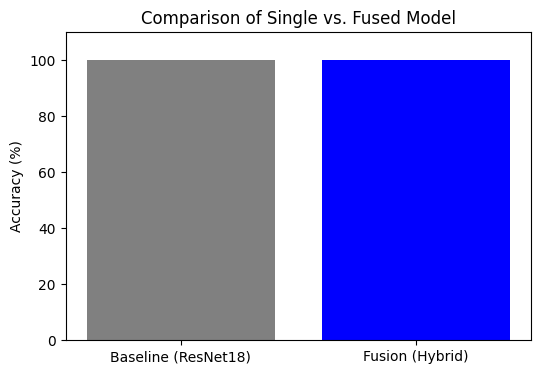

Baseline Accuracy: 100.0%
Fusion Accuracy: 100.0%
Improvement: 0.0%


In [4]:

def get_acc(m):
    m.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = m(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return (correct / total) * 100

# Get both scores
base_acc = get_acc(baseline_model)
fusion_acc = get_acc(model) # Your already trained Fusion model

# Plot results
plt.figure(figsize=(6, 4))
plt.bar(['Baseline (ResNet18)', 'Fusion (Hybrid)'], [base_acc, fusion_acc], color=['gray', 'blue'])
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Single vs. Fused Model')
plt.ylim(0, 110)
plt.show()

print(f"Baseline Accuracy: {base_acc}%")
print(f"Fusion Accuracy: {fusion_acc}%")
print(f"Improvement: {fusion_acc - base_acc}%")